In [1]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(":memory:")

conn.execute("""
CREATE TABLE restaurants (
    name TEXT,
    cuisine TEXT,
    rating REAL
)
""")

data = [
    ("The Food Hub", "Indian", 4.5),
    ("Pizza House", "Italian", 4.2),
    ("Spice Garden", "Indian", 4.7),
    ("Burger Point", "Fast Food", 4.0),
    ("Green Leaf", "Healthy", 4.6),
    ("Cafe Coffee", "Cafe", 4.1)
]

conn.executemany(
    "INSERT INTO restaurants VALUES (?, ?, ?)",
    data
)

df = pd.read_sql("SELECT * FROM restaurants", conn)

df.head()

,name,cuisine,rating
0,The Food Hub,Indian,4.5
1,Pizza House,Italian,4.2
2,Spice Garden,Indian,4.7
3,Burger Point,Fast Food,4.0
4,Green Leaf,Healthy,4.6


In [7]:
#2)In a Jupyter Notebook, use the %sql magic command to run a SQL query that selects all movies with a rating above 8 from a 'movies' table, and display the results in the notebook.
import sqlite3
import pandas as pd

# SQLite database
conn = sqlite3.connect(":memory:")

# Create movies table
conn.execute("""
CREATE TABLE movies (
    title TEXT,
    rating REAL
)
""")

# Insert data
conn.executemany(
    "INSERT INTO movies VALUES (?, ?)",
    [
        ("Inception", 8.8),
        ("Interstellar", 8.7),
        ("Avatar", 7.8),
        ("The Dark Knight", 9.0),
        ("Titanic", 7.9)
    ]
)

# SQL query
query = "SELECT * FROM movies WHERE rating > 8"

# Load SQL result directly into Pandas
df = pd.read_sql_query(query, conn)

# Display result
display(df)

conn.close()

,title,rating
0,Inception,8.8
1,Interstellar,8.7
2,The Dark Knight,9.0


In [8]:
#3)Combine SQL and Python to analyze Zomato-style order data: use pandas read_sql() to load the last 100 orders from an 'orders' table, then use DataFrame methods to find the top 3 most ordered food items.
import sqlite3
import pandas as pd

conn = sqlite3.connect(":memory:")

conn.execute("""
CREATE TABLE orders (
    order_id INTEGER,
    food_item TEXT,
    quantity INTEGER
)
""")

data = [
    (1, "Pizza", 2),
    (2, "Burger", 1),
    (3, "Biryani", 3),
    (4, "Pizza", 2),
    (5, "Biryani", 2),
    (6, "Burger", 3),
    (7, "Pizza", 4),
    (8, "Dosa", 2),
    (9, "Biryani", 4),
    (10, "Pizza", 3)
]

conn.executemany("INSERT INTO orders VALUES (?, ?, ?)", data)

df = pd.read_sql("""
SELECT *
FROM orders
ORDER BY order_id DESC
LIMIT 100
""", conn)

top_3 = df.groupby("food_item")["quantity"].sum().sort_values(ascending=False).head(3)

print("Top 3 Most Ordered Food Items:")
print(top_3)

conn.close()

Top 3 Most Ordered Food Items:
food_item
Pizza      11
Biryani     9
Burger      4
Name: quantity, dtype: int64


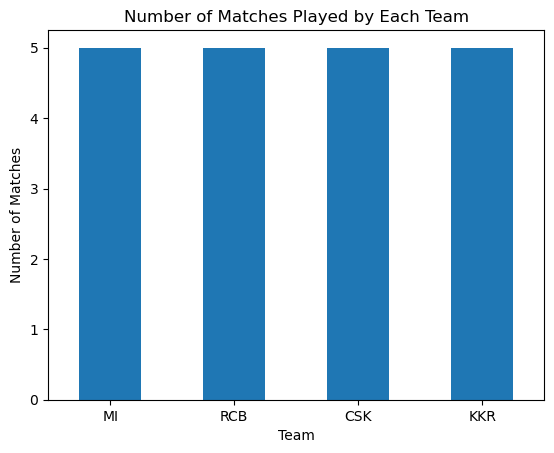

In [9]:
#4)After loading IPL match data from a 'matches' table into a pandas DataFrame, create a bar chart showing the number of matches played by each team using matplotlib or seaborn.<br><br><em><strong>Hint:</strong> Use groupby() in pandas to count matches per team before plotting.</em>
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Create SQLite database
conn = sqlite3.connect(":memory:")

# Create matches table
conn.execute("""
CREATE TABLE matches (
    match_id INTEGER,
    team1 TEXT,
    team2 TEXT
)
""")

# Sample IPL match data
data = [
    (1, "MI", "CSK"),
    (2, "RCB", "KKR"),
    (3, "MI", "RCB"),
    (4, "CSK", "KKR"),
    (5, "MI", "KKR"),
    (6, "RCB", "CSK"),
    (7, "MI", "CSK"),
    (8, "RCB", "MI"),
    (9, "KKR", "CSK"),
    (10, "RCB", "KKR")
]

conn.executemany(
    "INSERT INTO matches VALUES (?, ?, ?)", data
)

# Load matches table into Pandas
df = pd.read_sql("SELECT * FROM matches", conn)

# Count matches played by each team
team_matches = pd.concat([
    df["team1"],
    df["team2"]
]).value_counts()

# Create bar chart
team_matches.plot(kind="bar")

plt.title("Number of Matches Played by Each Team")
plt.xlabel("Team")
plt.ylabel("Number of Matches")
plt.xticks(rotation=0)
plt.show()

conn.close()

In [11]:
#5)Use ChatGPT or Copilot to help you write a Jupyter Notebook cell that connects to a SQLite database, runs a SQL query to fetch all users who have placed more than 5 orders, and loads the result into a pandas DataFrame.

import sqlite3
import pandas as pd

# SQLite database connection
conn = sqlite3.connect(":memory:")

# Create tables
conn.execute("""
CREATE TABLE users (
    user_id INTEGER PRIMARY KEY,
    name TEXT
)
""")

conn.execute("""
CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    user_id INTEGER
)
""")

# Insert users
conn.executemany("INSERT INTO users VALUES (?, ?)", [
    (1, "Rahul"),
    (2, "Priya"),
    (3, "Amit"),
    (4, "Neha")
])

# Insert orders
conn.executemany("INSERT INTO orders VALUES (?, ?)", [
    (1,1),(2,1),(3,1),(4,1),(5,1),(6,1),
    (7,2),(8,2),(9,2),
    (10,3),(11,3),(12,3),(13,3),(14,3),(15,3),(16,3),
    (17,4),(18,4)
])

conn.commit()

# SQL query: users who placed more than 5 orders
query = """
SELECT u.user_id, u.name, COUNT(o.order_id) AS total_orders
FROM users u
JOIN orders o ON u.user_id = o.user_id
GROUP BY u.user_id, u.name
HAVING COUNT(o.order_id) > 5
"""

# Load result into Pandas DataFrame
df = pd.read_sql(query, conn)

# Display result
display(df)

conn.close()

,user_id,name,total_orders
0,1,Rahul,6
1,3,Amit,7
